In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import datetime

yf.set_tz_cache_location(None)

tickers= ['SPY', 'AAPL', 'JPM', 'GS', 'BND']

end_date= datetime.date.today()
start_date= datetime.date(2020,1,1)

data= yf.download(tickers, start= start_date, end=end_date) ['Close']

print(data.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL        BND          GS         JPM         SPY
2020-01-02  72.333878  69.486740  202.118881  118.430305  296.888062
2020-01-03  71.630661  69.735001  199.755478  116.867462  294.640076
2020-01-06  72.201408  69.652283  201.799759  116.774551  295.764069
2020-01-07  71.861832  69.594315  203.128113  114.789314  294.932526
2020-01-08  73.017845  69.486740  205.086197  115.684799  296.504333


In [13]:
returns= data.pct_change().dropna()
print (returns.head())

Ticker          AAPL       BND        GS       JPM       SPY
2020-01-03 -0.009722  0.003573 -0.011693 -0.013196 -0.007572
2020-01-06  0.007968 -0.001186  0.010234 -0.000795  0.003815
2020-01-07 -0.004703 -0.000832  0.006583 -0.017001 -0.002812
2020-01-08  0.016087 -0.001546  0.009640  0.007801  0.005329
2020-01-09  0.021241  0.001191  0.020357  0.003651  0.006781


In [15]:
weights = np.array([0.2,0.2,0.2,0.2,0.2])
portfolio_returns= returns.dot(weights)
print(portfolio_returns.head())

2020-01-03   -0.007722
2020-01-06    0.004007
2020-01-07   -0.003753
2020-01-08    0.007462
2020-01-09    0.010644
dtype: float64


In [19]:
risk_free_rate=0.05/252
excess_returns=portfolio_returns-risk_free_rate
sharpe_ratio=(excess_returns.mean()/excess_returns.std())*np.sqrt(252)
print(f"Sharpe Ratio: {sharpe_ratio:0.2f}")

Sharpe Ratio: 0.70


In [21]:
confidence_level=0.95
VaR = np.percentile(portfolio_returns, (1- confidence_level)*100)

print(f"Daily VaR (95%): {VaR:.4f}")
print(f"In dollar terms on a $100,000 portfolio: ${VaR * 100000:,.0f}")

Daily VaR (95%): -0.0175
In dollar terms on a $100,000 portfolio: $-1,746


In [22]:
downside_returns = excess_returns[excess_returns <0]

sortino_ratio = (excess_returns.mean() / downside_returns.std()) * np.sqrt(252)

print (f"Sortino Ratio: {sortino_ratio:.2f}")

Sortino Ratio: 0.91


In [23]:
cumulative_returns = (1 + portfolio_returns).cumprod()

rolling_max = cumulative_returns.cummax()

drawdown = (cumulative_returns - rolling_max) / rolling_max

max_drawdown = drawdown.min()

print(f"Max Drawdown: {max_drawdown:.4f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")

Max Drawdown: -0.3121
Max Drawdown: -31.21%


In [24]:
print("=" * 40)
print("   PORTFOLIO RISK DASHBOARD SUMMARY")
print("=" * 40)
print(f"Tickers:        {tickers}")
print(f"Weights:        Equal (20% each)")
print(f"Period:         2020-01-01 to Today")
print("-" * 40)
print(f"Sharpe Ratio:   {sharpe_ratio:.2f}")
print(f"Sortino Ratio:  {sortino_ratio:.2f}")
print(f"Daily VaR 95%:  ${VaR * 100000:,.0f}")
print(f"Max Drawdown:   {max_drawdown * 100:.2f}%")
print("=" * 40)

   PORTFOLIO RISK DASHBOARD SUMMARY
Tickers:        ['SPY', 'AAPL', 'JPM', 'GS', 'BND']
Weights:        Equal (20% each)
Period:         2020-01-01 to Today
----------------------------------------
Sharpe Ratio:   0.70
Sortino Ratio:  0.91
Daily VaR 95%:  $-1,746
Max Drawdown:   -31.21%


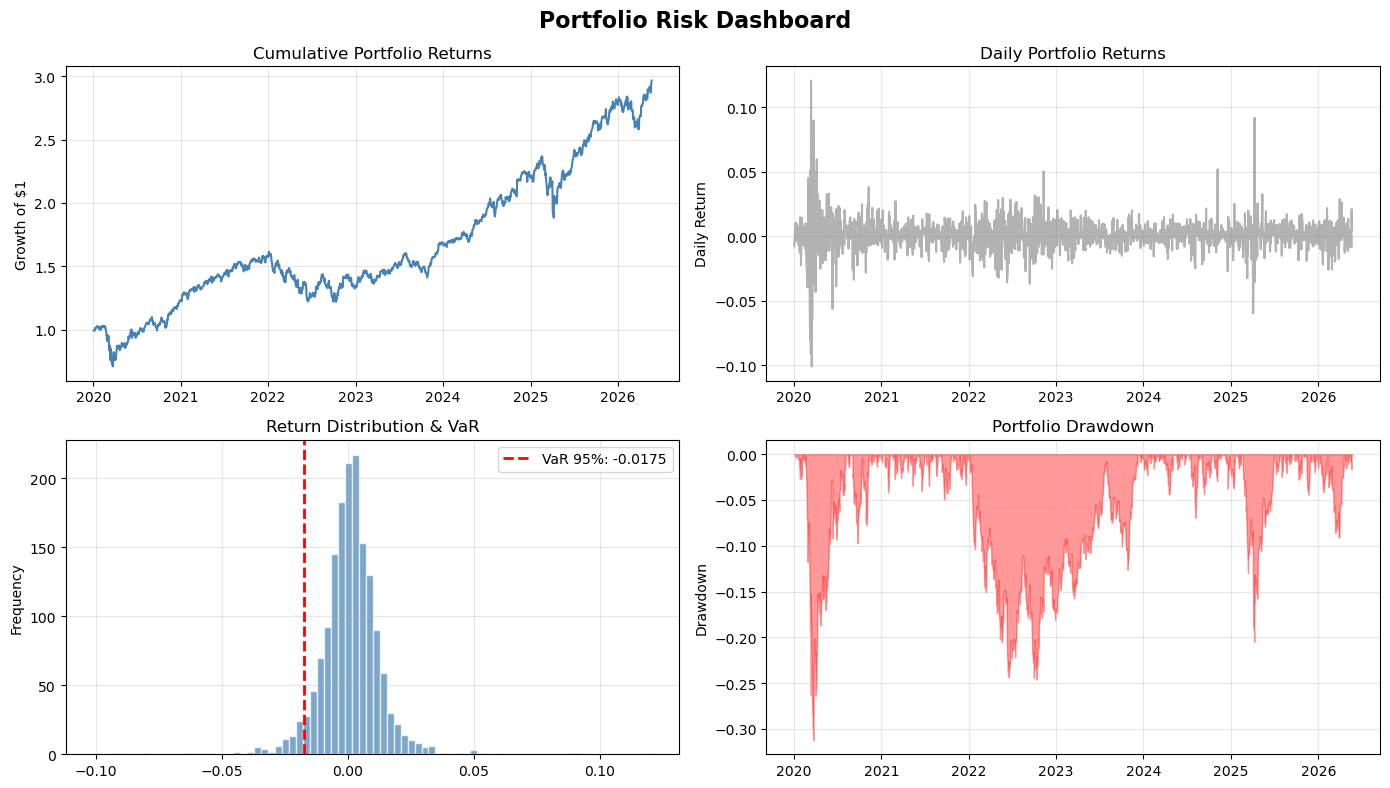

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Portfolio Risk Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Cumulative Returns
axes[0, 0].plot(cumulative_returns.index, cumulative_returns.values, color='steelblue')
axes[0, 0].set_title('Cumulative Portfolio Returns')
axes[0, 0].set_ylabel('Growth of $1')
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: Daily Returns
axes[0, 1].plot(portfolio_returns.index, portfolio_returns.values, color='gray', alpha=0.6)
axes[0, 1].set_title('Daily Portfolio Returns')
axes[0, 1].set_ylabel('Daily Return')
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Return Distribution with VaR line
axes[1, 0].hist(portfolio_returns, bins=80, color='steelblue', edgecolor='white', alpha=0.7)
axes[1, 0].axvline(VaR, color='red', linestyle='--', linewidth=2, label=f'VaR 95%: {VaR:.4f}')
axes[1, 0].set_title('Return Distribution & VaR')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Drawdown
axes[1, 1].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4)
axes[1, 1].set_title('Portfolio Drawdown')
axes[1, 1].set_ylabel('Drawdown')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()